<a href="https://colab.research.google.com/github/pab-h/seminarios-computacao/blob/main/lab/plant_village.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e Pré-processamento do Dataset PlantVillage

Este notebook demonstra como carregar, organizar, visualizar e pré-processar o dataset PlantVillage, com base na metodologia descrita no artigo de referência.

**Sobre o Dataset PlantVillage:**
* **Total de Classes:** 38 classes.
* **Distribuição:** 43.444 imagens de treinamento e 10.861 de validação.
* **Conteúdo:** 14 espécies de culturas e 17 doenças comuns, além de folhas saudáveis.
* **Formato:** Imagens RGB em formato JPG, capturadas em ambiente de laboratório controlado.

In [1]:
# O ponto de exclamação avisa ao Colab que isso é um comando de terminal (bash)
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 25.18 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# Configurando sementes para reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

## 1. Organização e Carregamento

Assumindo que você baixou o dataset e o extraiu, a estrutura de pastas geralmente segue o padrão `nome_da_classe/imagem.jpg`. Vamos usar a função `image_dataset_from_directory` do Keras para carregar os dados de forma eficiente.

In [3]:
# Apontando para a pasta de imagens coloridas (RGB) baixadas do GitHub
dataset_dir = '/content/PlantVillage-Dataset/raw/color'

# Definindo parâmetros iniciais
BATCH_SIZE = 16
IMG_HEIGHT_ORIGINAL = 256
IMG_WIDTH_ORIGINAL = 256

# ... (o restante do código continua exatamente igual)

# Definindo parâmetros iniciais
BATCH_SIZE = 16 # O artigo utiliza batch size de 16 [cite: 300]
IMG_HEIGHT_ORIGINAL = 256 # Tamanho original comum das imagens PlantVillage
IMG_WIDTH_ORIGINAL = 256

print("Carregando dataset de treinamento e validação...")

# Carregando o dataset sem redimensionar ainda para mostrar o original
raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2, # Proporção baseada nos números do artigo (aprox 20% validação) [cite: 192]
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT_ORIGINAL, IMG_WIDTH_ORIGINAL),
  batch_size=BATCH_SIZE)

raw_val_dataset = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT_ORIGINAL, IMG_WIDTH_ORIGINAL),
  batch_size=BATCH_SIZE)

class_names = raw_train_dataset.class_names
print(f"Total de classes encontradas: {len(class_names)}")

Carregando dataset de treinamento e validação...
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total de classes encontradas: 38


## 2. Visualizando Exemplos

Vamos visualizar algumas imagens originais do dataset antes de aplicar o pré-processamento.

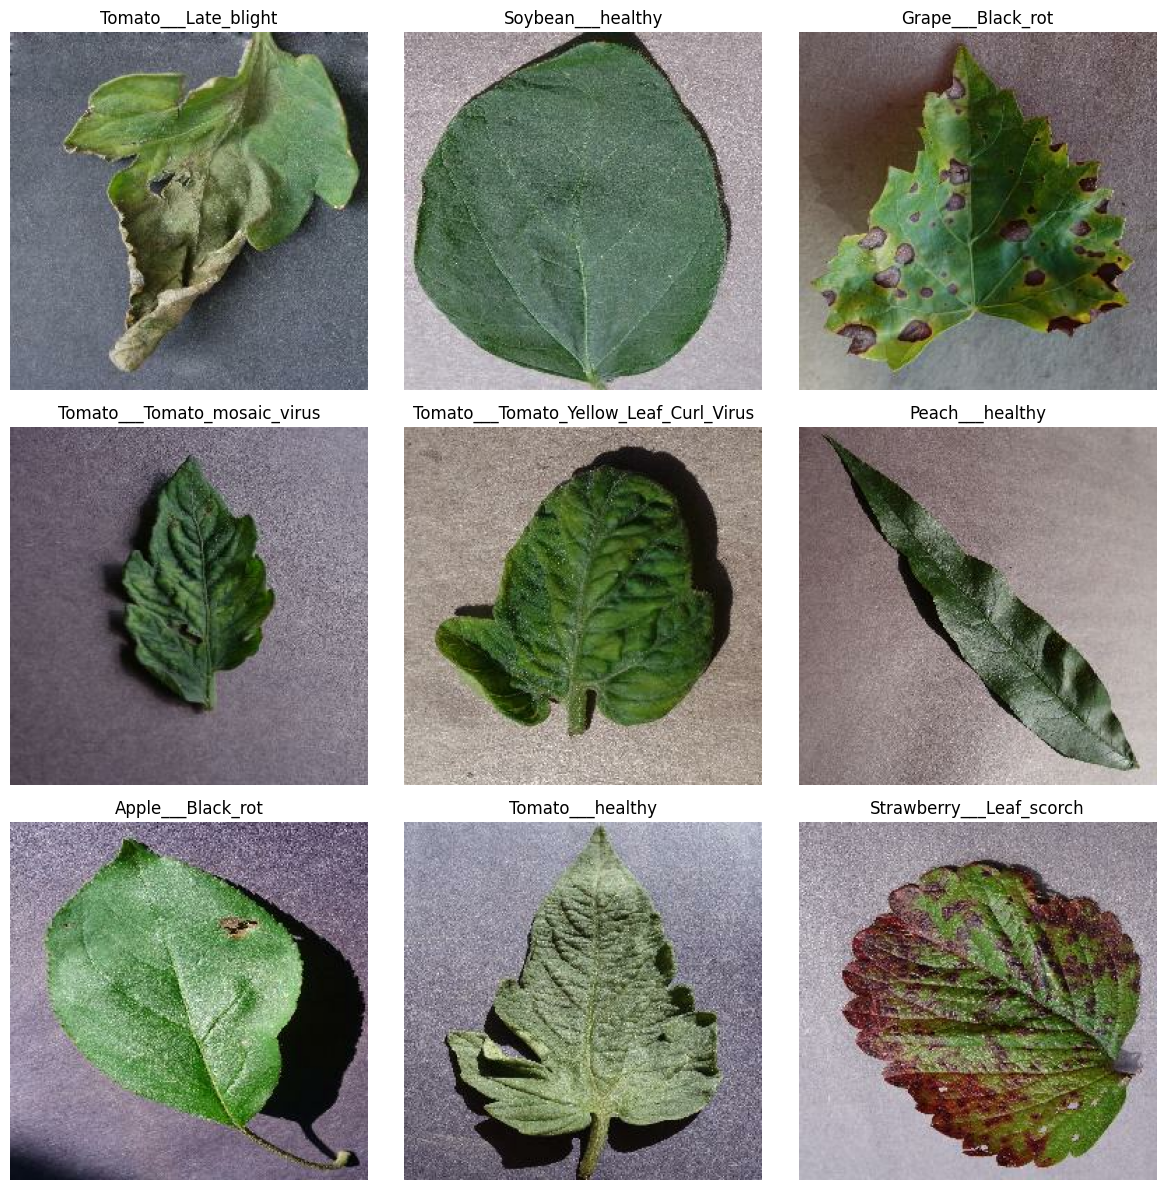

In [4]:
plt.figure(figsize=(12, 12))
for images, labels in raw_train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convertendo para uint8 para exibir corretamente a imagem
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Pré-processamento Baseado no Artigo

O artigo descreve os seguintes passos fundamentais para o pré-processamento da entrada do modelo Mob-Res:
1. **Redimensionamento:** O modelo proposto processa imagens de entrada com dimensões $128 \times 128 \times 3$.
2. **Normalização:** Os pixels da imagem são normalizados para o intervalo de valores entre 0 e 1.

In [5]:
# Parâmetros definidos pelo artigo
TARGET_IMG_SIZE = 128 # O modelo processa imagens 128x128x3 [cite: 113]

# Função de pré-processamento
def preprocess_image(image, label):
    # 1. Redimensionamento para 128x128
    image = tf.image.resize(image, [TARGET_IMG_SIZE, TARGET_IMG_SIZE])
    # 2. Normalização para o intervalo [0, 1]
    image = image / 255.0
    return image, label

# Aplicando o mapeamento aos datasets
train_dataset = raw_train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = raw_val_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Otimizando a performance com cache e prefetch
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Pré-processamento concluído: Imagens redimensionadas para 128x128 e normalizadas para [0, 1].")

Pré-processamento concluído: Imagens redimensionadas para 128x128 e normalizadas para [0, 1].


In [6]:
# Verificando as dimensões e o intervalo dos pixels após o pré-processamento
image_batch, label_batch = next(iter(train_dataset))

print("Formato do batch de imagens:", image_batch.shape)
print("Formato do batch de labels:", label_batch.shape)
print("Valor máximo do pixel no batch:", np.max(image_batch[0]))
print("Valor mínimo do pixel no batch:", np.min(image_batch[0]))

Formato do batch de imagens: (16, 128, 128, 3)
Formato do batch de labels: (16,)
Valor máximo do pixel no batch: 0.85490197
Valor mínimo do pixel no batch: 0.0
